# Curso: Redes Neurais para Processamento de Linguagem Natural

Prof. [Denilson Alves Pereira](https://sites.google.com/ufla.br/denilsonpereira) <br>
Departamento de Ciência da Computação (DCC) <br>
Instituto de Ciências Exatas e Tecnológicas (ICET) <br> 
Universidade Federal de Lavras (UFLA)

## Classificação de Textos usando o Modelo BERT

Objetivo: apresentar um exemplo da tarefa de classificação de textos usando o Modelo BERT.

Classificação de texto é uma tarefa de PLN que atribui um rótulo (ou classe) a um texto. Um exemplo popular de classificação de texto é a mineração de opinião (ou mais genericamente, análise de sentimentos), a qual atribui um rótulo como 🙂 positivo, 🙁 negativo, ou 😐 neutro a uma sequência de texto.

Você vai aprender a:
- Usar a biblioteca Datasets
- Pré-processar textos usando um tokenizador
- Fazer um ajuste fino (finetune) do modelo DistilBERT usando o dataset Rotten Tomatoes para determinar se a revisão de um filme é positiva ou negativa
- Avaliar o modelo ajustado e usá-lo para fazer inferências

Referências: <br>
https://huggingface.co/docs/transformers/tasks/sequence_classification <br>
https://huggingface.co/course/chapter1/1

Versão: Dezembro, 2022

## Pacotes

In [18]:
import numpy as np # scientific computing
import tensorflow as tf  #  numerical computation using data flow graphs
from transformers import AutoTokenizer, DataCollatorWithPadding, pipeline  # API Transformer do Hugging Face
from transformers import create_optimizer, TFAutoModelForSequenceClassification  # API Transformer do Hugging Face
from transformers.keras_callbacks import KerasMetricCallback  # API Transformer do Hugging Face
from datasets import load_dataset  # função para carga de datasets da biblioteca Datasets
import evaluate  # biblioteca de métricas de avaliação experimental
import matplotlib.pyplot as plt # scientific plotting library
from datetime import datetime # data e hora
from sklearn.metrics import accuracy_score, precision_recall_fscore_support # metricas de avaliação

## Pré-Processamento dos Dados

### Carga do Dataset

Dataset (base de dados): Rotten Tomatoes da biblioteca Datasets (https://huggingface.co/datasets/rotten_tomatoes)

O dataset contém dois atributos:
- text: o texto da revisão do filme
- label: o rótulo de classificação do filme. O valor é "0" para uma revisão negativa ou "1" para uma revisão positiva

A biblioteca 🤗 Datasets fornece um comando para baixar e colocar em cache um dataset do Hub do Hugging Face.<br>
O objeto DatasetDict resultante da carga contém as partições do conjunto de dados, e cada partição contém um conjunto de atributos (features) e uma variável com o número de linhas que ela possui.

Hub de datasets do Hugging Face: https://huggingface.co/datasets

In [19]:
# Carrega o dataset Rotten Tomatoes da biblioteca Datasets
db = load_dataset("rotten_tomatoes")
# Exibe a estrutura do dataset
db

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 8530
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1066
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1066
    })
})

In [20]:
# Mostra os rótulos da dataset de treino
db["train"].features["label"]

ClassLabel(names=['neg', 'pos'], id=None)

In [21]:
# Mostra as três primeiras revisões do dataset de teste
db["test"][:3]

{'text': ['lovingly photographed in the manner of a golden book sprung to life , stuart little 2 manages sweetness largely without stickiness .',
  'consistently clever and suspenseful .',
  'it\'s like a " big chill " reunion of the baader-meinhof gang , only these guys are more harmless pranksters than political activists .'],
 'label': [1, 1, 1]}

### Tokenização pelo Modelo DistilBERT

Carrega o tokenizador DistilBERT para pré-processar o atributo "text" do dataset:

In [22]:
# Carrega o tokenizador DistilBERT
checkpoint = "distilbert-base-uncased" # DistilBERT em inglês com tokens convertidos para minúsculas
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

Cria uma função de pré-processamento para tokenizar o texto e truncar as sequências maiores do que o comprimento máximo de entrada do modelo DistilBERT:

In [23]:
def preprocess_function(examples):
    return tokenizer(examples["text"], truncation=True)

A função "map" da biblioteca 🤗 Datasets pode ser usada para aplicar a função "preprocess_function", definida acima, para todo o dataset. O argumento "batched=True" indica que o processamento deve ser feito em lote de múltiplos elementos do dataset, o que torna a função "map" mais rápida.

In [24]:
tokenized_db = db.map(preprocess_function, batched=True)

Map:   0%|          | 0/1066 [00:00<?, ? examples/s]

Map: 100%|██████████| 1066/1066 [00:00<00:00, 4848.21 examples/s]


"DataCollatorWithPadding" cria um lote usando uma lista de elementos de um dataset como entrada. Durante o processamento, podem ser aplicados "padding", por exemplo. Na chamada abaixo, o argumento "padding" é por padrão igual a "True", o que faz o preenchimento (padding) pela sequência mais longa no lote. É mais eficiente preencher dinamicamente as sentenças pelo comprimento mais longo no lote durante o agrupamento (collation) do que preencher todo o dataset com o comprimento máximo.

In [25]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="tf")

## Configuração para Avaliação de Desempenho do Modelo

A biblioteca sklearn.metrics fornece um conjunto de métodos para avaliação do desempenho de modelos e datasets de aprendizagem de máquina.

Uma outra biblioteca também pode ser usada: https://huggingface.co/docs/evaluate/a_quick_tour

Função que retorna as métricas, a partir das predições e rótulos passados como parâmetro:

In [26]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    #compute precision, recall, and F1 score
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='macro')
    #compute accuracy score
    acc = accuracy_score(labels, predictions)
    return {"accuracy": acc, 
            "f1": f1,
            "precision": precision,
            "recall": recall
            }

## Treinamento do Modelo

Usaremos o DistilBERT pré-treinado e os dados de treinamento do dataset para fazer um ajuste fino (finetune) do modelo para a tarefa de classificação de opinião.

Criação de um mapeamento dos ids e seus rótulos:

In [27]:
id2label = {0: "NEGATIVE", 1: "POSITIVE"}
label2id = {"NEGATIVE": 0, "POSITIVE": 1}

Configuração de uma função de otimização para definir um escalonamento de taxa de aprendizagem (learning rate) e alguns hiperparâmetros de treinamento.

Mais detalhes de como treinar um modelo TensorFlow com Keras: https://huggingface.co/docs/transformers/training#train-a-tensorflow-model-with-keras

In [28]:
batch_size = 16
#num_epochs = 3
num_epochs = 1
batches_per_epoch = len(tokenized_db["train"]) // batch_size
total_train_steps = int(batches_per_epoch * num_epochs)
optimizer, schedule = create_optimizer(init_lr=2e-5, num_warmup_steps=0, num_train_steps=total_train_steps)

Carrega o DistilBERT com TFAutoModelForSequenceClassification (https://huggingface.co/docs/transformers/main/en/model_doc/auto#transformers.TFAutoModelForSequenceClassification)

TFAutoModelForSequenceClassification é uma classe genérica de modelos que será instanciada com uma das classes de modelos da biblioteca (com um head de classificação de sequência) quando criado com o método from_pretrained() ou com o método from_config().

O head para classificação de sequência é uma camada linear no topo das saídas agrupadas (pooled) dos estados ocultos (hidden states) do modelo base (DistilBERT, nesse caso).

<img src="./figs/transformer-and-head.svg">
https://huggingface.co/course/chapter2/2?fw=tf

In [29]:
model = TFAutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=2, id2label=id2label, label2id=label2id)

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_transform.weight', 'vocab_layer_norm.weight', 'vocab_transform.bias', 'vocab_projector.bias', 'vocab_layer_norm.bias']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

Converte os datasets para o formato tf.data.Dataset com o prepare_tf_dataset().

In [30]:
tf_train_set = model.prepare_tf_dataset(
    tokenized_db["train"],
    shuffle=True,
    batch_size=batch_size,
    collate_fn=data_collator,
)

tf_validation_set = model.prepare_tf_dataset(
    tokenized_db["validation"],
    shuffle=False,
    batch_size=batch_size,
    collate_fn=data_collator,
)

tf_test_set = model.prepare_tf_dataset(
    tokenized_db["test"],
    shuffle=False,
    batch_size=batch_size,
    collate_fn=data_collator,
)

You're using a DistilBertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Exibe a arquitetura e parâmetros do modelo:

In [31]:
model.summary()

Model: "tf_distil_bert_for_sequence_classification_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 distilbert (TFDistilBertMa  multiple                  66362880  
 inLayer)                                                        
                                                                 
 pre_classifier (Dense)      multiple                  590592    
                                                                 
 classifier (Dense)          multiple                  1538      
                                                                 
 dropout_39 (Dropout)        multiple                  0         
                                                                 
Total params: 66955010 (255.41 MB)
Trainable params: 66955010 (255.41 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


Configura o modelo para treinamento:

In [32]:
model.compile(optimizer=optimizer)

Computa a acurácia das predições:

In [33]:
metric_callback = KerasMetricCallback(metric_fn=compute_metrics, eval_dataset=tf_validation_set)
callbacks = [metric_callback]

Chama o método "fit" para treinar o modelo com os datasets de treino e validação:

In [34]:
start_time = datetime.now()
# Treino
history = model.fit(x=tf_train_set, validation_data=tf_validation_set, epochs=num_epochs, callbacks=callbacks)
# Tempo de treino
end_time = datetime.now()
training_time = (end_time - start_time).total_seconds()

533/533 [==============================] - 1343s 2s/step - loss: 0.4195 - val_loss: 0.3487 - accuracy: 0.8499 - f1: 0.8499 - precision: 0.8501 - recall: 0.8499


Visualização do Desempenho do Modelo<br>
Exibe gráficos de performance do modelo treinado.

In [35]:
print(history.history.keys())

dict_keys(['loss', 'val_loss', 'accuracy', 'f1', 'precision', 'recall'])


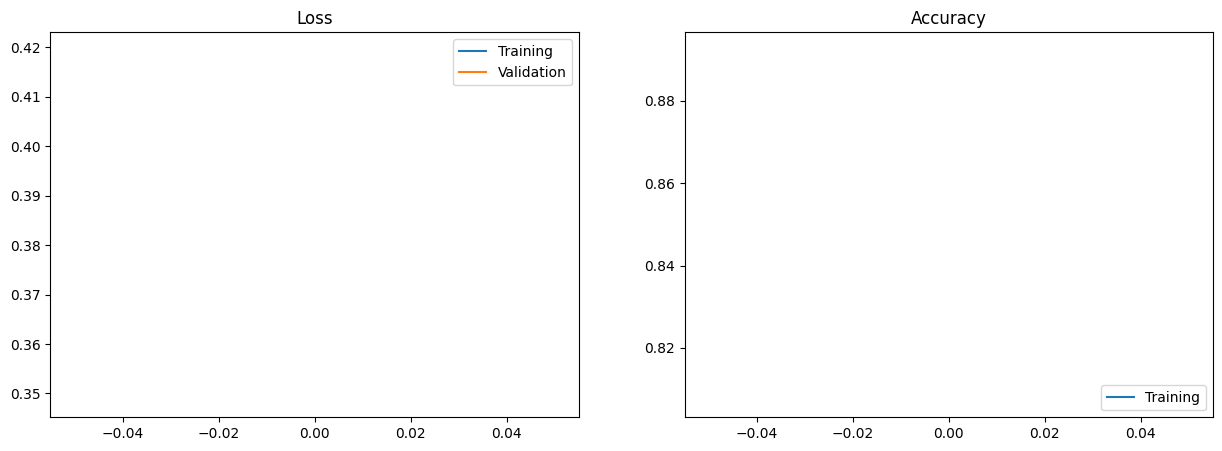

In [36]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
ax[0].set(title='Loss')
ax[0].plot(history.history['loss'], label='Training')
ax[0].plot(history.history['val_loss'], label='Validation')
ax[0].legend(loc="upper right")

ax[1].set(title='Accuracy')
ax[1].plot(history.history['accuracy'], label='Training')
#ax[1].plot(history.history['val_accuracy'], label='Validation')
ax[1].legend(loc="lower right")

In [37]:
print('Treinamento:')
print('Acurária : {:.1%}'.format(history.history['accuracy'][-1]))
#print('Acurária nos dados de validação: {:.1%}'.format(history.history['val_accuracy'][-1]))
print('Precisão : {:.1%}'.format(history.history['precision'][-1]))
print('Revocação: {:.1%}'.format(history.history['recall'][-1]))
print('F1       : {:.1%}'.format(history.history['f1'][-1]))
print('Tempo de treinamento: {:.1f}s (or {:.1f} minutes)'.format(training_time, training_time/60))

Treinamento:
Acurária : 85.0%
Precisão : 85.0%
Revocação: 85.0%
F1       : 85.0%
Tempo de treinamento: 1343.9s (or 22.4 minutes)


Salva o modelo treinado:

In [38]:
dir_save_model = "./"+checkpoint+"-fine-tuned-sa-db"
tokenizer.save_pretrained(dir_save_model)
model.save_pretrained(dir_save_model)

## Avaliação do Modelo

Avalia o desempenho do modelo no conjunto de teste.

Na classificação multiclasse, *model.predict* retorna um vetor de probabilidades para cada classe. A função *argmax* retorna o índice do vetor com a maior probabilidade, indicando assim a classe predita.

In [39]:
def compute_metrics2(predictions, labels):
    #compute precision, recall, and F1 score
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='macro')
    #compute accuracy score
    acc = accuracy_score(labels, predictions)
    return {"accuracy": acc, 
            "f1": f1,
            "precision": precision,
            "recall": recall
            }

In [40]:
output_logits = model.predict(tf_test_set).logits
pred_labels = np.argmax(output_logits, axis=-1)
compute_metrics2(pred_labels, db["test"]["label"])

67/67 [==============================] - 43s 618ms/step


{'accuracy': 0.848968105065666,
 'f1': 0.8489456401102986,
 'precision': 0.8491758241758242,
 'recall': 0.848968105065666}

In [41]:
# Imprime as primeiras instâncias
print("Predição: ", pred_labels[:20])
print("Correto:  ", db["test"]["label"][:20])
print("Texto:    ", db["test"]["text"][:20])

Predição:  [1 1 0 1 0 1 1 0 1 1 1 0 0 1 0 1 1 1 1 1]
Correto:   [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Texto:     ['lovingly photographed in the manner of a golden book sprung to life , stuart little 2 manages sweetness largely without stickiness .', 'consistently clever and suspenseful .', 'it\'s like a " big chill " reunion of the baader-meinhof gang , only these guys are more harmless pranksters than political activists .', 'the story gives ample opportunity for large-scale action and suspense , which director shekhar kapur supplies with tremendous skill .', 'red dragon " never cuts corners .', 'fresnadillo has something serious to say about the ways in which extravagant chance can distort our perspective and throw us off the path of good sense .', 'throws in enough clever and unexpected twists to make the formula feel fresh .', 'weighty and ponderous but every bit as filling as the treat of the title .', "a real audience-pleaser that will strike a chord with a

## Predição

Prediz a saída de novos dados

<img src="./figs/transformer-pipeline.svg">
https://huggingface.co/course/chapter2/2?fw=tf

Vamos agora usar o modelo ajustado (finetuned) para fazer inferências.<br>
Cria um texto para que o modelo infira sua opinião:

In [42]:
#text = "This was a masterpiece. Not completely faithful to the books, but enthralling from beginning to end. Might be my favorite of the three."
#text = "I didn't like the movie, I'm going to read the book."
text = "it\'s like a big chill reunion of the baader-meinhof gang , only these guys are more harmless pranksters than political activists ."

Tokeniza o texto e retorna os tensores TensorFlow:

In [43]:
tokenizer = AutoTokenizer.from_pretrained(dir_save_model)
inputs = tokenizer(text, return_tensors="tf")

<b>Logits</b> é o vetor de predição pura (não normalizado) que o modelo de classificação gera, o qual é comumente passado para uma função de normalização. Se o modelo está resolvendo um problema de classificação multiclasse, os logits tipicamente tornam-se uma entrada para a função softmax. E esta então gera um vetor de probabilidades (normalizado) com um valor para cada classe possível.

Passa as entradas para o modelo e retorna os logits:

In [44]:
model = TFAutoModelForSequenceClassification.from_pretrained(dir_save_model)
output_logits = model(**inputs).logits

Some layers from the model checkpoint at ./distilbert-base-uncased-fine-tuned-sa-db were not used when initializing TFDistilBertForSequenceClassification: ['dropout_39']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFDistilBertForSequenceClassification were not initialized from the model checkpoint at ./distilbert-base-uncased-fine-tuned-sa-db and are newly initialized: ['dropout_59']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Gera a classe predita a partir dos logits:

In [45]:
predicted_class_id = np.argmax(output_logits, axis=-1)[0]
model.config.id2label[predicted_class_id]

'NEGATIVE'

Uma forma mais simples de usar o model ajustado (finetuned) para predição é por meio do pipeline(). Instancie um pipeline para análise de sentimentos com o seu modelo, e passe o texto para ele. O uso do pipeline() é equivalente ao código acima.

In [46]:
classifier = pipeline("sentiment-analysis", model=dir_save_model)
classifier(text)

Some layers from the model checkpoint at ./distilbert-base-uncased-fine-tuned-sa-db were not used when initializing TFDistilBertForSequenceClassification: ['dropout_39']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFDistilBertForSequenceClassification were not initialized from the model checkpoint at ./distilbert-base-uncased-fine-tuned-sa-db and are newly initialized: ['dropout_79']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[{'label': 'NEGATIVE', 'score': 0.7456509470939636}]

# Fim

Esses foram os passos para classificação de textos usando o Modelo BERT. Nesse notebook, nós usamos o modelo com sua configuração padrão. É possível também criar uma arquitetura personalizada. Mais detalhes no link:<br>
https://huggingface.co/docs/transformers/create_a_model

Este outro link abaixo também apresenta, no final do artigo, um exemplo de como criar uma arquitetura personalizada para classificação com Transformers. Ele mostra passo-a-passo como configurar as camadas da rede densa de classificação. Além disso, ele usa o dataset no formato do Pandas, e não do Datasets. <br>
https://medium.com/@claude.feldges/text-classification-with-tf-idf-lstm-bert-a-quantitative-comparison-b8409b556cb3

-------------------------------------------